# 02 Â· Sinais de ForÃ§a ” Features v1 + v2

**Objetivo:** calcular todas as features de forÃ§a que alimentam o `trigger_engine.py` v2.0.

### Features v1 (histÃ³ricas ” mantidas para referÃªncia)

| Feature | DescriÃ§Ã£o | Janela |
|---|---|---|
| `slope_Media_7d` | InclinaÃ§Ã£o regressÃ£o linear da MÃ©dia (N/dia) | 7 dias |
| `pct_abaixo_800N_7d` | % leituras com MÃ©dia < 800 N | 7 dias |
| `min_forca_3d` | MÃ­nimo da MÃ©dia | 3 dias |
| `cv_Delta_AB_7d` | CV do Delta_AB (std/mean) | 7 dias |

### Features v2 (gatilho RED + p_risk)

| Feature | DescriÃ§Ã£o | Janela |
|---|---|---|
| `mean_3d` | MÃ©dia 3d da forÃ§a (N) ” forÃ§a recente | 3 dias |
| `mean_14d` | MÃ©dia 14d da forÃ§a (N) ” baseline | 14 dias |
| `ratio_3_14` | `mean_3d / mean_14d` ” queda relativa | ” |
| `deg_signal` | `max(0, 1 âˆ’ ratio_3_14)` ” grau de degradaÃ§Ã£o | ” |
| `slope_danger` | `clip(âˆ’slope_7d / 50, 0, 1)` ” tendÃªncia normalizada | ” |
| `signal_score` | `deg_signalÃ—0.6 + slope_dangerÃ—0.4` âˆˆ [0,1] | ” |
| `proj_48h` | `mean_3d + slope_7dÃ—2` ” projeÃ§Ã£o de forÃ§a em 48h (N) | ” |
| `age_risk` | Weibull CDF(age_days) ” risco por idade âˆˆ [0,1] | ” |
| `p_risk` | `age_risk + (1âˆ’age_risk)Ã—signal_scoreÃ—0.65` âˆˆ [0,1] | ” |

| Etapa | DescriÃ§Ã£o |
|---|---|
| A | Carregar dados, atribuir ciclo_id |
| B | Calcular Media e Delta_AB |
| C | Features v1 de forÃ§a por janela (cycle-aware) |
| D | Features v2 ” indicadores p_risk (cycle-aware) |
| E | ValidaÃ§Ã£o visual |
| F | Exportar `02_sinais_forca.csv` |


In [2]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ARQUIVO_HOURLY    = '00_hour_prev.csv'
ARQUIVO_TROCAS    = '../troca_modulo.csv'
COLUNA_DATA_TROCA = 'Data-base do inicio'

# Limiares v1
FORCA_LIMIAR      = 800.0    # N ” limiar G_F1 / G_F2 / G_F3
SLOPE_THRESHOLD   = -50.0   # N/dia ” limiar de queda
WINDOW_7D         = '7D'
WINDOW_3D         = '3D'
MIN_PERIODS_SLOPE = 4        # mi­nimo de pontos para calcular slope

# Parametros Weibull v2 ” calibrados nos 26 ciclos FB14
WEIBULL_BETA = 1.181
WEIBULL_ETA_D = 54.05   # 1297h / 24
BOOST_SINAL  = 0.65

# Limiar projeçao v2
PROJ_LIMIAR   = 920.0   # N
print('Config OK')


Config OK


## Etapa A ” Carregar dados e atribuir ciclo_id

In [3]:
df = pd.read_csv(ARQUIVO_HOURLY, parse_dates=['Timestamp'])
df = df.rename(columns={'Timestamp': 'ts'})
df['ts'] = pd.to_datetime(df['ts'], utc=True)
df = df.sort_values('ts').reset_index(drop=True)

tc = pd.read_csv(ARQUIVO_TROCAS, parse_dates=[COLUNA_DATA_TROCA])
tc = tc.sort_values(COLUNA_DATA_TROCA).reset_index(drop=True)
troca_dates = pd.to_datetime(tc[COLUNA_DATA_TROCA]).dt.tz_localize('UTC').tolist()

# Atribuir ciclo_id e horas_desde_troca
df['ciclo_id']          = -1
df['horas_desde_troca'] = np.nan

limites = troca_dates + [pd.Timestamp.max.tz_localize('UTC')]
for i, (t_ini, t_fim) in enumerate(zip(limites[:-1], limites[1:])):
    mask = (df['ts'] >= t_ini) & (df['ts'] < t_fim)
    if not mask.any():
        continue
    df.loc[mask, 'ciclo_id']          = i
    df.loc[mask, 'horas_desde_troca'] = (
        (df.loc[mask, 'ts'] - t_ini).dt.total_seconds() / 3600
    ).values

print(f'Linhas : {len(df)}  |  {df["ts"].min().date()} â†’ {df["ts"].max().date()}')
print(f'Ciclos : {df["ciclo_id"].nunique() - 1} completos + ciclo atual')

Linhas : 3218  |  2022-06-27 â†’ 2026-05-10
Ciclos : 29 completos + ciclo atual


## Etapa B ” Media e Delta_AB

Recalculados internamente a partir de `Forca_A` e `Forca_B` ” independentes de
qualquer pipeline anterior.

In [4]:
df['Media']    = (df['Forca_A'] + df['Forca_B']) / 2.0
df['Delta_AB'] = (df['Forca_A'] - df['Forca_B']).abs()

validos = df['Media'].notna() & df['ciclo_id'].ge(0)

print('€€ EstatÃ­sticas globais (Media, N) €€€€€€€€€€€€€€€€€€€€')
print(df.loc[validos, 'Media'].describe().round(1).to_string())
print()
print(f'Leituras abaixo de {FORCA_LIMIAR:.0f} N : '
      f'{(df.loc[validos, "Media"] < FORCA_LIMIAR).sum()} '
      f'({(df.loc[validos, "Media"] < FORCA_LIMIAR).mean():.1%})')

€€ EstatÃ­sticas globais (Media, N) €€€€€€€€€€€€€€€€€€€€
count    3218.0
mean     1077.3
std       274.9
min       398.0
25%       884.1
50%      1047.8
75%      1264.8
max      2295.0

Leituras abaixo de 800 N : 478 (14.9%)


## Etapa C ” Features de forÃ§a por janela (cycle-aware)

Cada feature Ã© calculada dentro de cada ciclo separadamente para que a janela
rolante nÃ£o cruze o limite de uma troca.

In [5]:
def _slope_series(s_indexed, min_periods=MIN_PERIODS_SLOPE):
    """RegressÃ£o linear 7d sobre sÃ©rie com DatetimeIndex ” retorna inclinaÃ§Ã£o em N/dia."""
    def _slope_fn(w):
        if len(w) < min_periods:
            return np.nan
        t = (w.index - w.index[0]).total_seconds().values / 86400.0
        if t[-1] < 0.5:          # janela < 12h â†’ inclinaÃ§Ã£o instÃ¡vel
            return np.nan
        return np.polyfit(t, w.values, 1)[0]
    return s_indexed.rolling(WINDOW_7D, min_periods=min_periods).apply(
        _slope_fn, raw=False
    )


# Arrays de destino
n = len(df)
slope_arr   = np.full(n, np.nan)
pct_arr     = np.full(n, np.nan)
min3d_arr   = np.full(n, np.nan)
cv_dab_arr  = np.full(n, np.nan)

for ciclo_id in sorted(df['ciclo_id'].unique()):
    if ciclo_id < 0:
        continue

    mask = df['ciclo_id'] == ciclo_id
    sub  = df.loc[mask].copy()
    if sub['Media'].notna().sum() < 2:
        continue

    media_s  = pd.Series(sub['Media'].values,    index=sub['ts'])
    below_s  = (media_s < FORCA_LIMIAR).astype(float)
    dab_s    = pd.Series(sub['Delta_AB'].values, index=sub['ts'])

    # slope_Media_7d
    sl = _slope_series(media_s)
    slope_arr[mask.values] = sl.values

    # pct_abaixo_800N_7d
    pct_arr[mask.values] = below_s.rolling(WINDOW_7D, min_periods=1).mean().values

    # min_forca_3d
    min3d_arr[mask.values] = media_s.rolling(WINDOW_3D, min_periods=1).min().values

    # cv_Delta_AB_7d  (std / mean, sÃ³ quando mean > 0)
    r_std  = dab_s.rolling(WINDOW_7D, min_periods=4).std()
    r_mean = dab_s.rolling(WINDOW_7D, min_periods=4).mean()
    cv_dab_arr[mask.values] = np.where(r_mean > 0, r_std / r_mean, np.nan)

df['slope_Media_7d']     = slope_arr
df['pct_abaixo_800N_7d'] = pct_arr
df['min_forca_3d']       = min3d_arr
df['cv_Delta_AB_7d']     = cv_dab_arr

print('Features calculadas OK')
print(df[['slope_Media_7d', 'pct_abaixo_800N_7d', 'min_forca_3d', 'cv_Delta_AB_7d']]
      .describe().round(3).to_string())

Features calculadas OK
       slope_Media_7d  pct_abaixo_800N_7d  min_forca_3d  cv_Delta_AB_7d
count        3107.000            3218.000      3218.000        3107.000
mean            2.579               0.157       852.040           0.722
std            69.540               0.225       215.734           0.132
min          -551.197               0.000       397.950           0.080
25%           -28.989               0.000       715.550           0.633
50%            -0.948               0.062       823.700           0.717
75%            29.950               0.200       982.287           0.806
max           777.825               1.000      1939.450           1.615


## Etapa D ” Features v2: p_risk por dia (cycle-aware)

In [6]:
def _weibull_age_risk(age_days):
    if age_days <= 0:
        return 0.0
    return float(1.0 - np.exp(-((age_days / WEIBULL_ETA_D) ** WEIBULL_BETA)))


# Arrays de destino v2
n = len(df)
mean3_arr   = np.full(n, np.nan)
mean14_arr  = np.full(n, np.nan)
sigscore_arr = np.full(n, np.nan)
proj48_arr  = np.full(n, np.nan)
agerisk_arr = np.full(n, np.nan)
prisk_arr   = np.full(n, np.nan)

for ciclo_id in sorted(df['ciclo_id'].unique()):
    if ciclo_id < 0:
        continue

    mask = df['ciclo_id'] == ciclo_id
    sub  = df.loc[mask].copy()
    if sub['Media'].notna().sum() < 2:
        continue

    media_s = pd.Series(sub['Media'].values, index=sub['ts'])

    # MÃ©dias rolantes (dentro do ciclo)
    m3  = media_s.rolling('3D',  min_periods=1).mean()
    m14 = media_s.rolling('14D', min_periods=1).mean()
    mean3_arr[mask.values]  = m3.values
    mean14_arr[mask.values] = m14.values

    # Slope 7d (jÃ¡ calculado em slope_Media_7d)
    sl_vals = df.loc[mask, 'slope_Media_7d'].values

    # signal_score, proj_48h
    for j, (m3v, m14v, slv) in enumerate(zip(m3.values, m14.values, sl_vals)):
        if np.isnan(m3v) or np.isnan(m14v) or m14v == 0:
            continue
        ratio  = m3v / m14v
        deg    = max(0.0, 1.0 - ratio)
        danger = float(np.clip(-slv / 50.0, 0.0, 1.0)) if not np.isnan(slv) else 0.0
        ss     = deg * 0.6 + danger * 0.4
        sigscore_arr[mask.values.nonzero()[0][j]] = ss
        proj48_arr[mask.values.nonzero()[0][j]]   = m3v + (slv * 2.0 if not np.isnan(slv) else 0.0)

    # age_risk e p_risk (usa horas_desde_troca do df)
    age_d_vals = sub['horas_desde_troca'].values / 24.0
    for j, (age_d, ss) in enumerate(zip(age_d_vals, sigscore_arr[mask.values.nonzero()[0]])):
        ar = _weibull_age_risk(float(age_d) if not np.isnan(age_d) else 0.0)
        agerisk_arr[mask.values.nonzero()[0][j]] = ar
        if not np.isnan(ss):
            prisk_arr[mask.values.nonzero()[0][j]] = ar + (1.0 - ar) * ss * BOOST_SINAL

df['mean_3d']      = mean3_arr
df['mean_14d']     = mean14_arr
df['signal_score'] = sigscore_arr
df['proj_48h']     = proj48_arr
df['age_risk']     = agerisk_arr
df['p_risk']       = prisk_arr

# Colunas derivadas
df['ratio_3_14'] = np.where(mean14_arr > 0, mean3_arr / mean14_arr, np.nan)
df['deg_signal'] = np.clip(1.0 - df['ratio_3_14'].fillna(1.0), 0.0, None)

print('Features v2 calculadas OK')
print(df[['mean_3d', 'mean_14d', 'signal_score', 'proj_48h', 'age_risk', 'p_risk']]
      .describe().round(4).to_string())


Features v2 calculadas OK
         mean_3d   mean_14d  signal_score   proj_48h   age_risk     p_risk
count  3218.0000  3218.0000     3218.0000  3218.0000  3218.0000  3218.0000
mean   1074.6800  1079.4676        0.1428  1079.6596     0.4267     0.4780
std     225.2830   194.6662        0.1831   293.1455     0.2988     0.2848
min     491.0500   503.8250        0.0000  -149.0200     0.0000     0.0000
25%     926.6317   954.4314        0.0000   876.9777     0.1678     0.2726
50%    1052.6694  1061.9703        0.0373  1052.6400     0.3806     0.4616
75%    1215.2982  1217.9521        0.2679  1250.9083     0.6365     0.6775
max    2130.7143  1939.4500        0.6764  2870.4670     0.9861     0.9896


In [7]:
#  Estado atual 
ultimo = df[df['ciclo_id'] >= 0].iloc[-1]

print(' Estado atual do ciclo ')
print(f'  Timestamp          : {ultimo["ts"]}')
print(f'  horas_desde_troca  : {ultimo["horas_desde_troca"]:.1f}h  '
      f'({ultimo["horas_desde_troca"]/24:.1f} dias)')
print(f'  Media              : {ultimo["Media"]:.1f} N')
print(f'  Delta_AB           : {ultimo["Delta_AB"]:.1f} N')
print()
print('   Indicadores v1 ')
print(f'  slope_Media_7d     : {ultimo["slope_Media_7d"]:.2f} N/dia  '
      f'({"ALERTA" if ultimo["slope_Media_7d"] < SLOPE_THRESHOLD else "OK"})')
print(f'  pct_abaixo_800N_7d : {ultimo["pct_abaixo_800N_7d"]:.1%}  '
      f'({"ALERTA" if ultimo["pct_abaixo_800N_7d"] > 0 else "OK"})')
print(f'  min_forca_3d       : {ultimo["min_forca_3d"]:.1f} N  '
      f'({"ALERTA" if ultimo["min_forca_3d"] < FORCA_LIMIAR else "OK"})')
print()
print('   Indicadores v2 (gatilho RED) ')
print(f'  mean_3d            : {ultimo["mean_3d"]:.1f} N')
print(f'  mean_14d           : {ultimo["mean_14d"]:.1f} N')
print(f'  ratio_3_14         : {ultimo["ratio_3_14"]:.4f}')
print(f'  signal_score       : {ultimo["signal_score"]:.4f}')
print(f'  proj_48h           : {ultimo["proj_48h"]:.1f} N  '
      f'({"ABAIXO LIMIAR 920N" if ultimo["proj_48h"] < PROJ_LIMIAR else "ok"})')
print(f'  age_risk (Weibull) : {ultimo["age_risk"]:.4f}')
print(f'  p_risk             : {ultimo["p_risk"]:.4f}  '
      f'({ultimo["p_risk"]*100:.1f}% prob. impacto)')


 Estado atual do ciclo 
  Timestamp          : 2026-05-10 23:01:54+00:00
  horas_desde_troca  : 119.0h  (5.0 dias)
  Media              : 1643.0 N
  Delta_AB           : 82.0 N

   Indicadores v1 
  slope_Media_7d     : 31.00 N/dia  (OK)
  pct_abaixo_800N_7d : 7.7%  (ALERTA)
  min_forca_3d       : 995.6 N  (OK)

   Indicadores v2 (gatilho RED) 
  mean_3d            : 1240.9 N
  mean_14d           : 1242.3 N
  ratio_3_14         : 0.9989
  signal_score       : 0.0007
  proj_48h           : 1302.9 N  (ok)
  age_risk (Weibull) : 0.0578
  p_risk             : 0.0582  (5.8% prob. impacto)


## Etapa D ” ValidaÃ§Ã£o visual

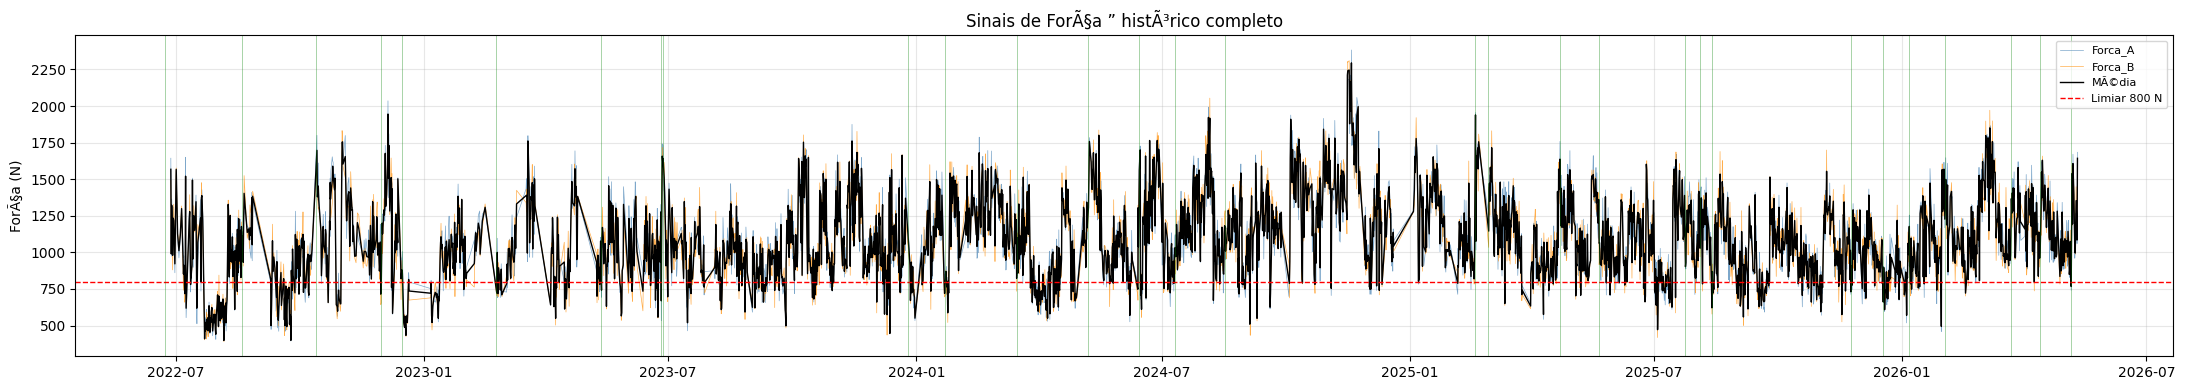

In [8]:
# Figura 1 ” Forca_A, Forca_B e Media com limiar 800N
fig, ax = plt.subplots(figsize=(22, 4))

validos = df['Media'].notna() & df['ciclo_id'].ge(0)
ax.plot(df.loc[validos, 'ts'], df.loc[validos, 'Forca_A'],
        lw=0.5, color='steelblue', alpha=0.7, label='Forca_A')
ax.plot(df.loc[validos, 'ts'], df.loc[validos, 'Forca_B'],
        lw=0.5, color='darkorange', alpha=0.7, label='Forca_B')
ax.plot(df.loc[validos, 'ts'], df.loc[validos, 'Media'],
        lw=1.0, color='black', label='MÃ©dia')
ax.axhline(FORCA_LIMIAR, color='red', ls='--', lw=1.0,
           label=f'Limiar {FORCA_LIMIAR:.0f} N')

tc_genuinas = []
# Marcar trocas
for i in range(len(troca_dates) - 1):
    ax.axvline(troca_dates[i + 1], color='green', lw=0.6, alpha=0.4)

ax.set_ylabel('ForÃ§a (N)')
ax.set_title('Sinais de ForÃ§a ” histÃ³rico completo')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('02_forca_serie.png', dpi=120, bbox_inches='tight')
plt.show()

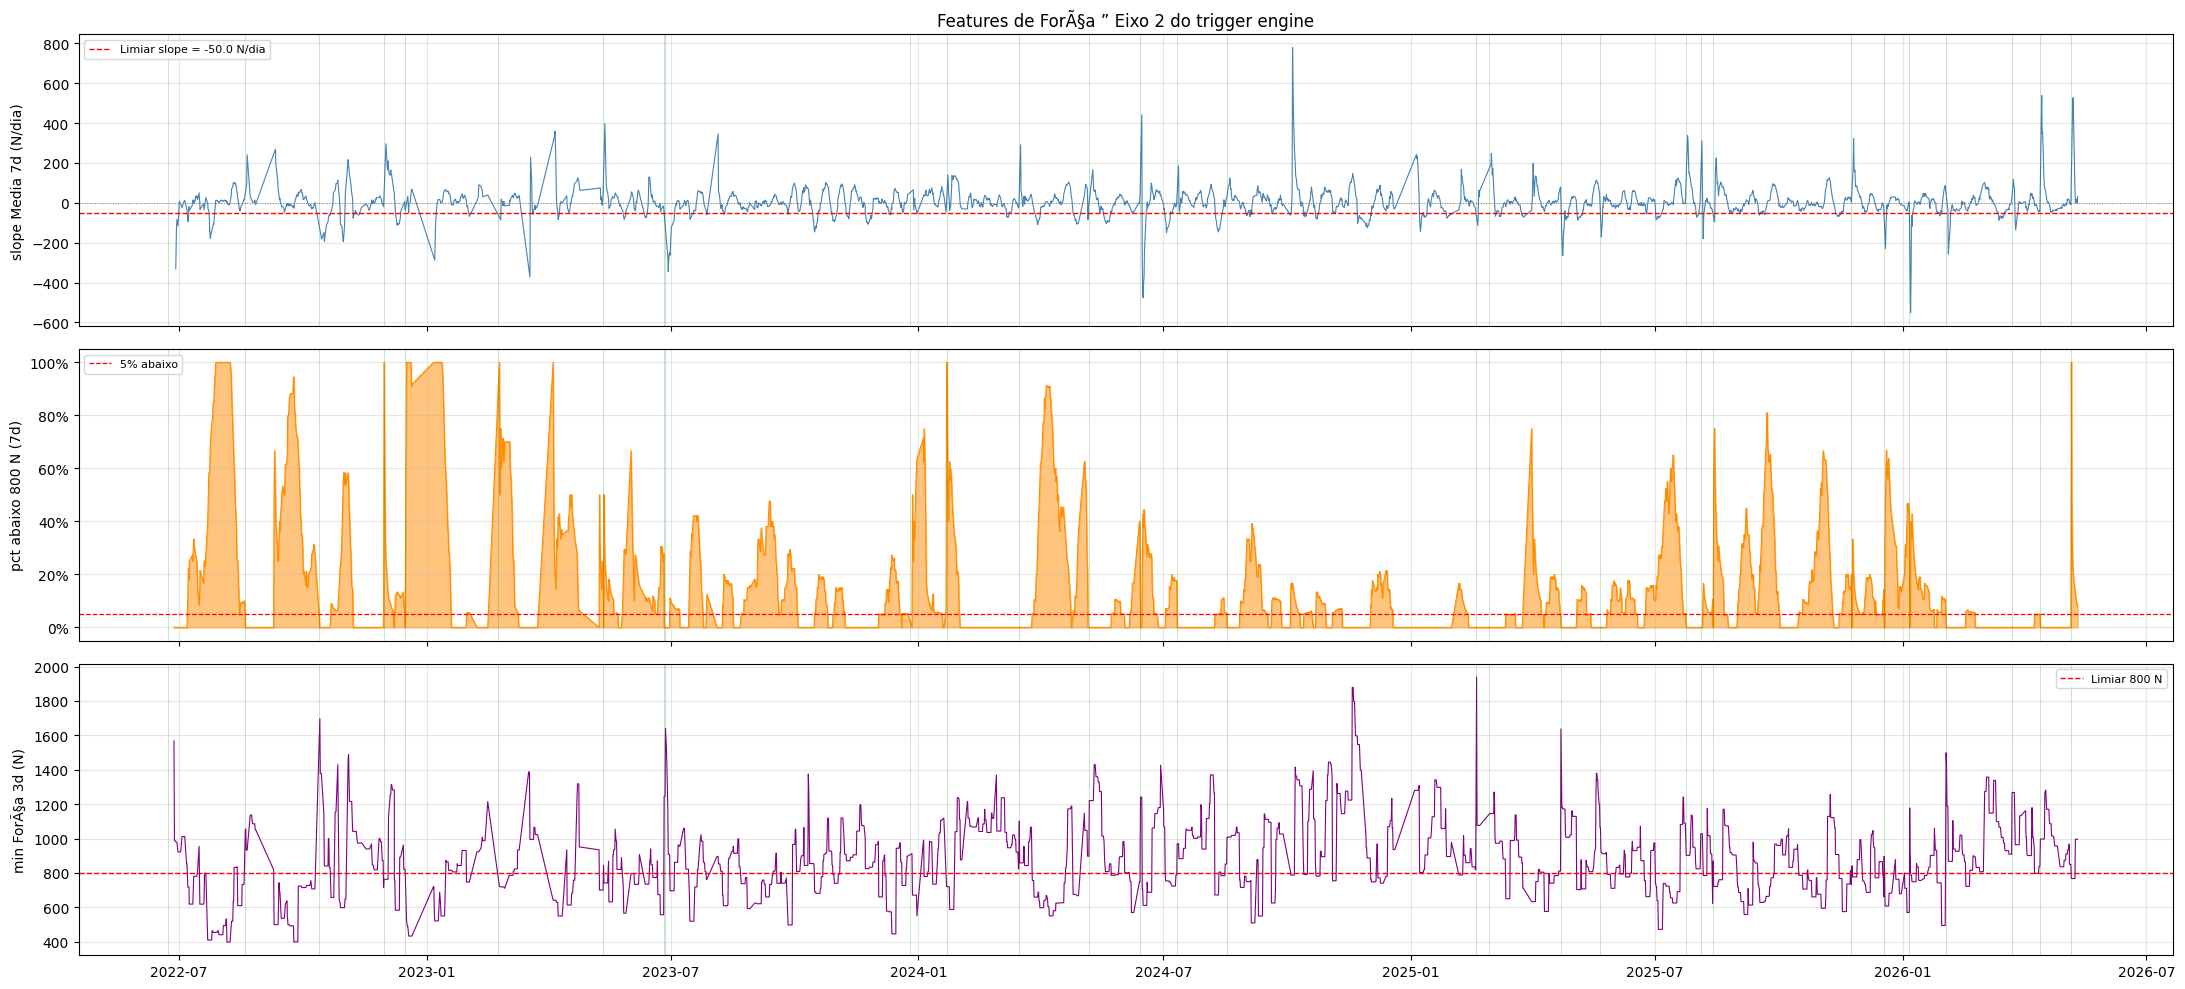

In [9]:
# Figura 2 ” Features de forÃ§a: slope, pct_abaixo, min_forca
fig, axes = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

mask_feat = df['slope_Media_7d'].notna()

# slope_Media_7d
axes[0].plot(df.loc[mask_feat, 'ts'], df.loc[mask_feat, 'slope_Media_7d'],
             lw=0.8, color='steelblue')
axes[0].axhline(SLOPE_THRESHOLD, color='red', ls='--', lw=1.0,
                label=f'Limiar slope = {SLOPE_THRESHOLD} N/dia')
axes[0].axhline(0, color='gray', ls=':', lw=0.7)
axes[0].set_ylabel('slope Media 7d (N/dia)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# pct_abaixo_800N_7d
mask_pct = df['pct_abaixo_800N_7d'].notna()
axes[1].fill_between(df.loc[mask_pct, 'ts'], df.loc[mask_pct, 'pct_abaixo_800N_7d'],
                     color='darkorange', alpha=0.5)
axes[1].plot(df.loc[mask_pct, 'ts'], df.loc[mask_pct, 'pct_abaixo_800N_7d'],
             lw=0.8, color='darkorange')
axes[1].axhline(0.05, color='red', ls='--', lw=0.9, label='5% abaixo')
axes[1].set_ylabel('pct abaixo 800 N (7d)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# min_forca_3d
mask_min = df['min_forca_3d'].notna()
axes[2].plot(df.loc[mask_min, 'ts'], df.loc[mask_min, 'min_forca_3d'],
             lw=0.8, color='purple')
axes[2].axhline(FORCA_LIMIAR, color='red', ls='--', lw=1.0,
                label=f'Limiar {FORCA_LIMIAR:.0f} N')
axes[2].set_ylabel('min ForÃ§a 3d (N)')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

for ax in axes:
    for t in troca_dates[1:]:
        ax.axvline(t, color='green', lw=0.5, alpha=0.3)

axes[0].set_title('Features de ForÃ§a ” Eixo 2 do trigger engine')
plt.tight_layout()
plt.savefig('02_features_forca.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# â”€â”€ Quantas vezes cada feature cruzou o limiar por ciclo â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€”€”€
resumo = []
for i, (t_ini, t_fim) in enumerate(zip(troca_dates[:-1], troca_dates[1:])):
    sub = df[(df['ts'] >= t_ini) & (df['ts'] < t_fim)]
    if sub.empty:
        continue
    resumo.append({
        'ciclo_id'         : i,
        'troca_fim'        : t_fim.date(),
        'dur_dias'         : round((t_fim - t_ini).total_seconds() / 86400, 0),
        'slope_min'        : round(sub['slope_Media_7d'].min(), 1) if sub['slope_Media_7d'].notna().any() else None,
        'slope_alarm'      : int((sub['slope_Media_7d'] < SLOPE_THRESHOLD).any()),
        'pct_max'          : round(sub['pct_abaixo_800N_7d'].max(), 3) if sub['pct_abaixo_800N_7d'].notna().any() else None,
        'pct_alarm'        : int((sub['pct_abaixo_800N_7d'] > 0).any()),
        'min_forca_min'    : round(sub['min_forca_3d'].min(), 0) if sub['min_forca_3d'].notna().any() else None,
        'min_alarm'        : int((sub['min_forca_3d'] < FORCA_LIMIAR).any()),
    })

resumo_df = pd.DataFrame(resumo)
print(f'Ciclos com slope_alarm  : {resumo_df["slope_alarm"].sum()} / {len(resumo_df)}')
print(f'Ciclos com pct_alarm    : {resumo_df["pct_alarm"].sum()} / {len(resumo_df)}')
print(f'Ciclos com min_alarm    : {resumo_df["min_alarm"].sum()} / {len(resumo_df)}')
print()
display(resumo_df)

Ciclos com slope_alarm  : 25 / 29
Ciclos com pct_alarm    : 25 / 29
Ciclos com min_alarm    : 25 / 29



,ciclo_id,troca_fim,dur_dias,slope_min,slope_alarm,pct_max,pct_alarm,min_forca_min,min_alarm
0,1,2022-08-19,57.0,-330.7,1,1.000,1,398.0,1
1,2,2022-10-13,55.0,-48.1,0,0.944,1,399.0,1
2,3,2022-11-30,48.0,-195.1,1,0.583,1,598.0,1
3,4,2022-12-16,16.0,-112.9,1,1.000,1,583.0,1
4,5,2023-02-23,69.0,-287.3,1,1.000,1,433.0,1
5,6,2023-05-12,78.0,-372.8,1,1.000,1,550.0,1
6,7,2023-06-26,45.0,-83.0,1,0.667,1,557.0,1
7,8,2023-06-27,1.0,NaN,0,0.000,0,1246.0,0
8,9,2023-12-26,182.0,-344.9,1,0.476,1,446.0,1
9,10,2024-01-22,27.0,-56.6,1,0.750,1,550.0,1


## Etapa E - Visualizacao v2: p_risk e signal_score

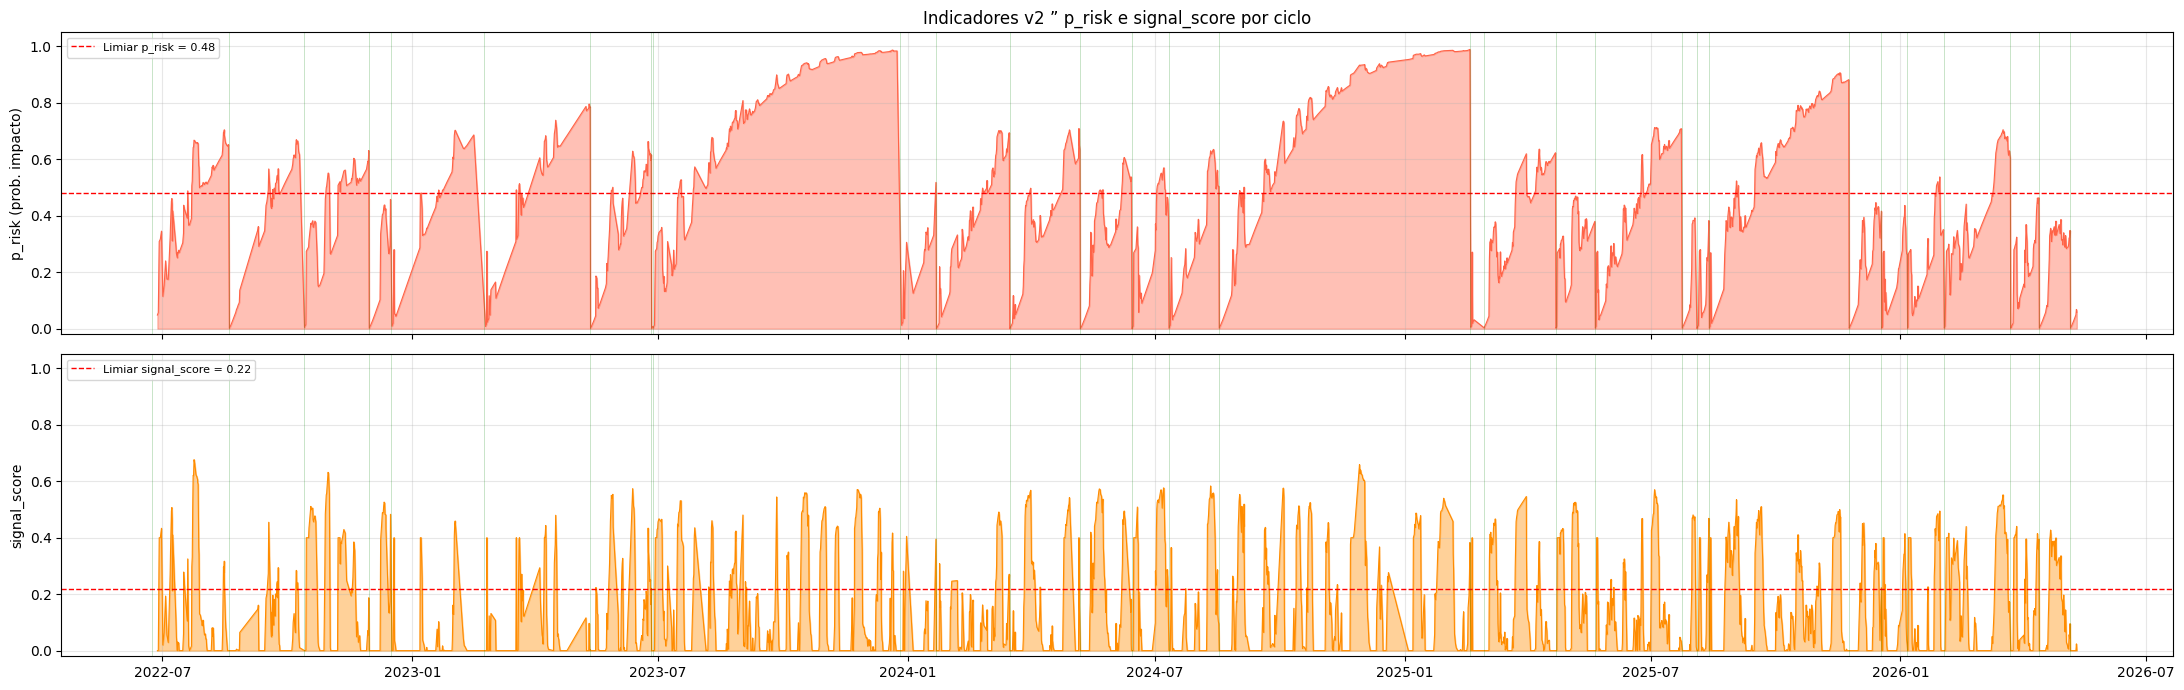

In [11]:
# Figura 3 ” p_risk e signal_score ao longo do tempo
fig, axes = plt.subplots(2, 1, figsize=(22, 7), sharex=True)

mask_v2 = df['p_risk'].notna()

# p_risk
axes[0].fill_between(df.loc[mask_v2, 'ts'], df.loc[mask_v2, 'p_risk'],
                     color='tomato', alpha=0.4)
axes[0].plot(df.loc[mask_v2, 'ts'], df.loc[mask_v2, 'p_risk'],
             lw=0.8, color='tomato')
axes[0].axhline(0.48, color='red', ls='--', lw=1.0, label='Limiar p_risk = 0.48')
axes[0].set_ylabel('p_risk (prob. impacto)')
axes[0].set_ylim(-0.02, 1.05)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# signal_score
mask_ss = df['signal_score'].notna()
axes[1].fill_between(df.loc[mask_ss, 'ts'], df.loc[mask_ss, 'signal_score'],
                     color='darkorange', alpha=0.4)
axes[1].plot(df.loc[mask_ss, 'ts'], df.loc[mask_ss, 'signal_score'],
             lw=0.8, color='darkorange')
axes[1].axhline(0.22, color='red', ls='--', lw=1.0, label='Limiar signal_score = 0.22')
axes[1].set_ylabel('signal_score')
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

for ax in axes:
    for t in troca_dates[1:]:
        ax.axvline(t, color='green', lw=0.5, alpha=0.3)

axes[0].set_title('Indicadores v2 ” p_risk e signal_score por ciclo')
plt.tight_layout()
plt.savefig('02_prisk_series.png', dpi=120, bbox_inches='tight')
plt.show()


## Etapa F ” Exportar `02_sinais_forca.csv`

In [12]:
cols_export = [
    'ts', 'ciclo_id', 'horas_desde_troca',
    'Forca_A', 'Forca_B', 'Media', 'Delta_AB',
    # v1
    'slope_Media_7d', 'pct_abaixo_800N_7d', 'min_forca_3d', 'cv_Delta_AB_7d',
    # v2
    'mean_3d', 'mean_14d', 'ratio_3_14', 'deg_signal',
    'signal_score', 'proj_48h', 'age_risk', 'p_risk',
]

out = df[[c for c in cols_export if c in df.columns]].copy()
out = out.rename(columns={'ts': 'Timestamp'})
out.to_csv('02_sinais_forca.csv', index=False)

print(f'Exportado: 02_sinais_forca.csv  ({len(out)} linhas)')
print()
print('Colunas v2 exportadas: mean_3d, mean_14d, ratio_3_14, deg_signal, signal_score, proj_48h, age_risk, p_risk')
print()
print('ultimas 3 linhas (v2):')
v2cols = ['Timestamp', 'ciclo_id', 'horas_desde_troca', 'Media',
          'mean_3d', 'signal_score', 'proj_48h', 'age_risk', 'p_risk']
import IPython.display as idp
idp.display(out[v2cols].tail(3).round(4))


Exportado: 02_sinais_forca.csv  (3218 linhas)

Colunas v2 exportadas: mean_3d, mean_14d, ratio_3_14, deg_signal, signal_score, proj_48h, age_risk, p_risk

ultimas 3 linhas (v2):


,Timestamp,ciclo_id,horas_desde_troca,Media,mean_3d,signal_score,proj_48h,age_risk,p_risk
3215,2026-05-10 07:01:37+00:00,30,103.0269,1209.9,1250.1125,0.0000,1275.7927,0.0490,0.0490
3216,2026-05-10 15:33:27+00:00,30,111.5575,1084.3,1183.4643,0.0238,1180.6634,0.0537,0.0683
3217,2026-05-10 23:01:54+00:00,30,119.0317,1643.0,1240.9062,0.0007,1302.9035,0.0578,0.0582
